In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Problem statement
Amazon is expanding its AI-powered customer service ecosystem and enterprise AI services through cloud infrastructure, automation, AI assistants, and connected service platforms. This expansion creates opportunities for operational efficiency, customer experience improvement, and market growth. However, it also introduces strategic, operational, technological, cybersecurity, financial, compliance, and governance risks. This risk assessment evaluates Amazon-related risks using likelihood and impact scores, then applies a Random Forest classifier and a risk heat map to support ERM-based prioritization.

In [2]:
# Load the Amazon Risk Register workbook
# Keep the Excel file in the same folder as this notebook when running locally.

file_path = "ALY6130_Risk Register_Group3_Amazon.xlsx"

# Backup filename if the workbook was downloaded with a duplicate suffix
if not os.path.exists(file_path):
    file_path = "ALY6130_Risk Register_Group3_Amazon(1).xlsx"

# Read the Risk Register sheet from the workbook
# Only the required columns are selected because the original workbook contains multiple template sections.
df_risk_register = pd.read_excel(
    file_path,
    sheet_name="RiskRegister",
    usecols=["Risk #", "The Risk of/That", "Likelihood Score", "Impact Score"]
)

# Preview the first few rows
df_risk_register.head()

,Risk #,The Risk of/That,Likelihood Score,Impact Score
0,1,Failure of AI warehouse strategy to achieve ex...,5,8
1,2,Public backlash over workforce replacement,3,6
2,3,Competitors implementing superior warehouse te...,9,8
3,4,Dependence on third party technology vendors,7,4
4,5,Warehouse operations interruption,7,9


In [3]:
# Select and rename relevant columns
risk_df = df_risk_register[
    ['Risk #', 'The Risk of/That', 'Likelihood Score', 'Impact Score']
].dropna().copy()

risk_df.columns = ['Risk_ID', 'Risk_Description', 'Likelihood_Score', 'Impact_Score']

# Make sure scores are numeric
risk_df['Risk_ID'] = pd.to_numeric(risk_df['Risk_ID'], errors='coerce').astype(int)
risk_df['Likelihood_Score'] = pd.to_numeric(risk_df['Likelihood_Score'], errors='coerce')
risk_df['Impact_Score'] = pd.to_numeric(risk_df['Impact_Score'], errors='coerce')
risk_df = risk_df.dropna(subset=['Likelihood_Score', 'Impact_Score']).copy()

# Calculate total risk score
risk_df['Risk_Score'] = risk_df['Likelihood_Score'] * risk_df['Impact_Score']

# Define severity label based on teacher-style heat map zones
# Low  = lower likelihood area
# Medium = middle risk area
# High = upper-right high-risk area
def classify_severity(row):
    likelihood = row['Likelihood_Score']
    impact = row['Impact_Score']

    if impact >= 9 or (likelihood >= 9 and impact >= 8):
        return 'High'
    elif likelihood <= 3:
        return 'Low'
    else:
        return 'Medium'

# Apply function to classify severity
risk_df['Severity_Label'] = risk_df.apply(classify_severity, axis=1)

# Create label used in charts
risk_df['Label'] = 'R' + risk_df['Risk_ID'].astype(str) + ' (' + risk_df['Severity_Label'] + ')'

# View cleaned data
risk_df.head()

,Risk_ID,Risk_Description,Likelihood_Score,Impact_Score,Risk_Score,Severity_Label,Label
0,1,Failure of AI warehouse strategy to achieve ex...,5,8,40,Medium,R1 (Medium)
1,2,Public backlash over workforce replacement,3,6,18,Low,R2 (Low)
2,3,Competitors implementing superior warehouse te...,9,8,72,High,R3 (High)
3,4,Dependence on third party technology vendors,7,4,28,Medium,R4 (Medium)
4,5,Warehouse operations interruption,7,9,63,High,R5 (High)


In [4]:
from sklearn.ensemble import RandomForestClassifier

# This model uses a Random Forest classifier to predict risk severity levels based on likelihood and impact scores.
# A shallow max_depth is used to reduce overfitting and make the model evaluation less mechanically perfect.
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=2,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

In [5]:
# Re-select features and target: defines the feature matrix (X) using Likelihood and Impact scores,
# and creates the target variable (y) using the rule-based severity labels.
X = risk_df[['Likelihood_Score', 'Impact_Score']]
y = risk_df['Severity_Label']

# Check class distribution before model evaluation
print("Severity class distribution:")
print(y.value_counts())

Severity class distribution:
Severity_Label
Medium    22
Low        9
High       6
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Use stratified cross-validation because the dataset is small but contains multiple severity classes.
# This gives a more stable evaluation than a single train-test split.
n_splits = min(5, y.value_counts().min())
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

print(f"Mean accuracy ({n_splits}-fold CV): {scores.mean():.2f}")
print("Accuracy for each fold:", scores)

Mean accuracy (5-fold CV): 0.92
Accuracy for each fold: [0.875      1.         1.         0.85714286 0.85714286]


### Note:
The model accuracy should be interpreted with caution because the severity labels are derived from the same likelihood and impact scores used as model features. The Random Forest model is included to follow the analytical notebook structure, but the main risk assessment decision should still come from the risk register, thresholds, and heat map.

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix

# Cross-validated predictions
y_pred_cv = cross_val_predict(model, X, y, cv=cv)

# Classification metrics
print("Classification Report:")
print(classification_report(y, y_pred_cv, labels=['Low', 'Medium', 'High'], zero_division=0))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High']))

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         9
      Medium       0.95      0.91      0.93        22
        High       0.71      0.83      0.77         6

    accuracy                           0.92        37
   macro avg       0.89      0.91      0.90        37
weighted avg       0.93      0.92      0.92        37

Confusion Matrix:
[[ 9  0  0]
 [ 0 20  2]
 [ 0  1  5]]


The classification results show how consistently the rule-based severity categories can be reproduced from likelihood and impact scores. Since the target severity is based on these two scores, the model should be interpreted as a supporting validation exercise rather than an independent predictive finding.

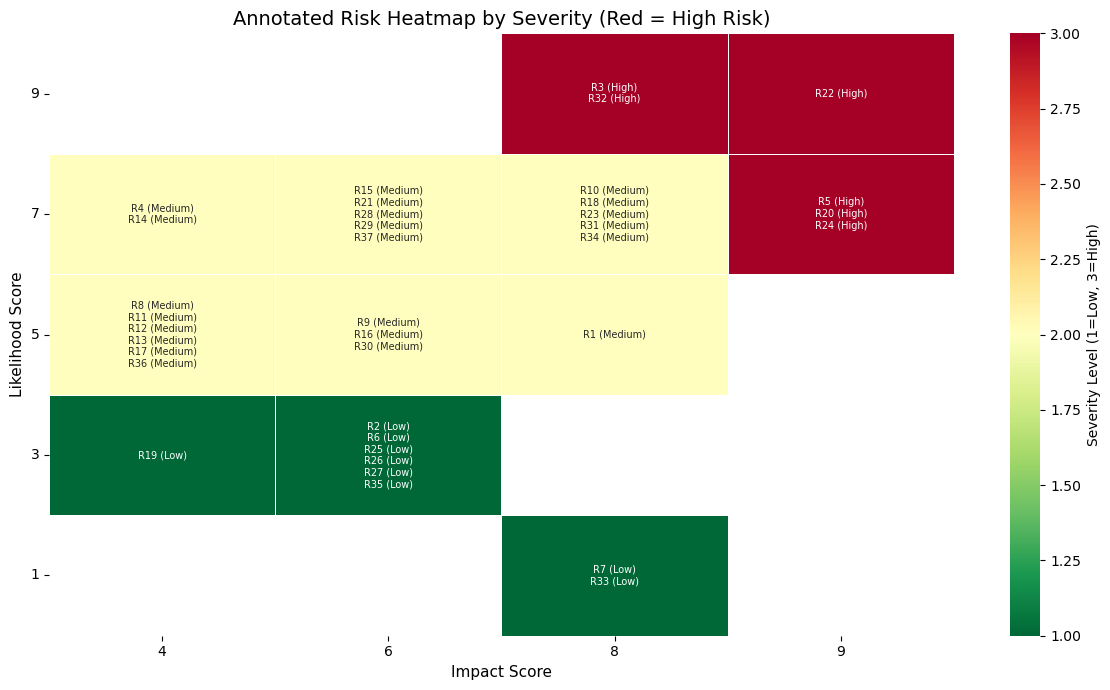

In [8]:
# Create severity map for risk heat map
severity_map = risk_df.copy()

# Map severity to numeric scale
severity_levels = {'Low': 1, 'Medium': 2, 'High': 3}
severity_map['Severity_Num'] = severity_map['Severity_Label'].map(severity_levels)

# Pivot table with most severe risk per likelihood-impact cell
pivot_severity = severity_map.groupby(
    ['Likelihood_Score', 'Impact_Score']
)['Severity_Num'].max().unstack()

pivot_severity = pivot_severity.sort_index(ascending=False)
pivot_severity = pivot_severity[pivot_severity.columns.sort_values()]

# Annotation matrix with risk IDs and severity labels
label_matrix = severity_map.groupby(
    ['Likelihood_Score', 'Impact_Score']
)['Label'].apply(lambda x: chr(10).join(x)).unstack(fill_value='')

label_matrix = label_matrix.sort_index(ascending=False)
label_matrix = label_matrix[label_matrix.columns.sort_values()]

# Match label matrix to color matrix
label_matrix = label_matrix.reindex(
    index=pivot_severity.index,
    columns=pivot_severity.columns,
    fill_value=''
)

# Make blank cells white
cmap = plt.cm.get_cmap('RdYlGn_r').copy()
cmap.set_bad(color='white')

# Plot severity heatmap with annotations using teacher-style format
plt.figure(figsize=(12, 7))
ax = sns.heatmap(
    pivot_severity,
    annot=label_matrix,
    fmt='',
    cmap=cmap,
    vmin=1,
    vmax=3,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Severity Level (1=Low, 3=High)'},
    annot_kws={'fontsize': 7, 'ha': 'center', 'va': 'center'}
)

plt.title("Annotated Risk Heatmap by Severity (Red = High Risk)", fontsize=14)
plt.xlabel("Impact Score", fontsize=11)
plt.ylabel("Likelihood Score", fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

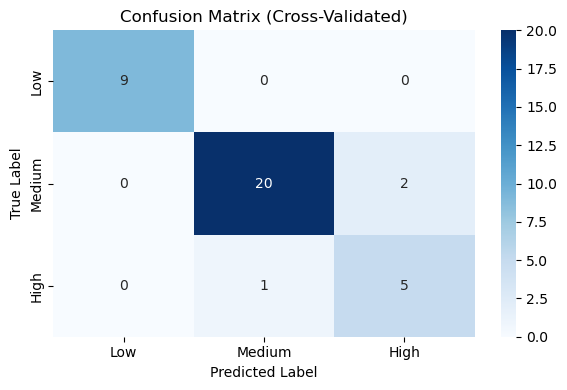

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict

# Reuse model and labels
y_pred_cv = cross_val_predict(model, X, y, cv=cv)
conf_matrix = confusion_matrix(y, y_pred_cv, labels=['Low', 'Medium', 'High'])

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)
plt.title("Confusion Matrix (Cross-Validated)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Interpretation
The confusion matrix shows how well the Random Forest model reproduces the Low, Medium, and High severity categories based on likelihood and impact scores. Because the categories are rule-based and derived from the same two input scores, the result should not be interpreted as a fully independent prediction model. Instead, it supports the consistency of the risk classification logic used in the ERM heat map.

In [10]:
# Summary of risks by severity level
severity_summary = risk_df.groupby('Severity_Label').agg(
    Number_of_Risks=('Risk_ID', 'count'),
    Average_Likelihood=('Likelihood_Score', 'mean'),
    Average_Impact=('Impact_Score', 'mean'),
    Average_Risk_Score=('Risk_Score', 'mean')
).reindex(['Low', 'Medium', 'High'])

severity_summary

,Number_of_Risks,Average_Likelihood,Average_Impact,Average_Risk_Score
Severity_Label,,,,
Low,9,2.555556,6.222222,15.111111
Medium,22,6.090909,5.818182,36.181818
High,6,8.000000,8.666667,69.000000


In [11]:
# Top 10 risks by total risk score
top_10_risks = risk_df.sort_values('Risk_Score', ascending=False).head(10)

top_10_risks[[
    'Risk_ID',
    'Risk_Description',
    'Likelihood_Score',
    'Impact_Score',
    'Risk_Score',
    'Severity_Label'
]]

,Risk_ID,Risk_Description,Likelihood_Score,Impact_Score,Risk_Score,Severity_Label
21,22,Customer data breach,9,9,81,High
2,3,Competitors implementing superior warehouse te...,9,8,72,High
31,32,Data privacy violations,9,8,72,High
4,5,Warehouse operations interruption,7,9,63,High
23,24,Ransomware attacks,7,9,63,High
19,20,Cloud service outage,7,9,63,High
17,18,Integration failure between legacy systems and...,7,8,56,Medium
33,34,AI ethics concerns,7,8,56,Medium
30,31,Revenue loss from delivery disruptions,7,8,56,Medium
9,10,Supply chain disruption,7,8,56,Medium
